In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation 
from IPython.display import HTML

# Euler

In [2]:
#Euler - need to update position, velocity, and accel in both x and y
def Euler(x,y,vx,vy,time,dt):
    '''
    x, y, vx, and vy are the initial params given. Time is how long I want the loop to go for and dt is the step size. 
    '''

    x_vals = [x]
    y_vals = [y]
    vx_vals = [vx]
    vy_vals = [vy]
    
    #calculate initial energy
    r = np.sqrt(x**2 + y**2)
    e = 0.5*(vx**2 + vy**2) - G*M/r
    
    e_vals = [e]
  
    steps = int(time/dt) 
    
    for i in range(steps):
        r = np.sqrt(x**2 + y**2) #compute position first

        #accel in x and y from position
        ax = -G*M*x/r**3
        ay = -G*M*y/r**3

        x_new  = x + vx*dt
        y_new  = y + vy*dt
        vx_new = vx + ax*dt
        vy_new = vy + ay*dt

        #calc energies
        r_new = np.sqrt(x_new**2 + y_new**2)
        e = 0.5*(vx_new**2 + vy_new**2) - G*M/r_new
        
        #updating params 
        x = x_new
        y = y_new
        vx = vx_new
        vy = vy_new
        
        x_vals.append(x)
        y_vals.append(y)
        vx_vals.append(vx)
        vy_vals.append(vy)
        e_vals.append(e)

    t_vals = np.linspace(0, time, steps + 1)

    return np.array(x_vals), np.array(y_vals), np.array(vx_vals), np.array(vy_vals), np.array(e_vals), t_vals

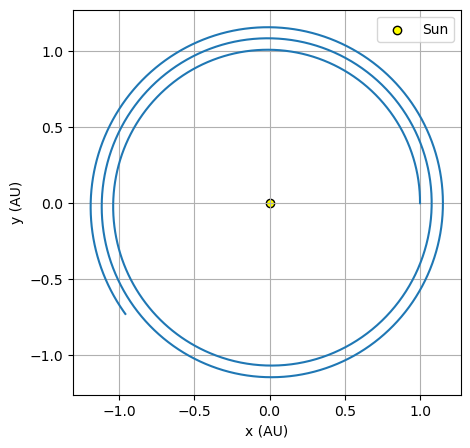

In [3]:
#testing Euler
#Orbital mech eqns - but need to do in x and y. Using params given by hw
G = 4*np.pi**2
M = 1 #solar mass
x, y = 1,0 #AU
r = np.sqrt(x**2+y**2)
vcirc = np.sqrt(G*M/r)

x,y,vx,vy,e,t = Euler(x,y,0,vcirc,3,0.001)

plt.figure(figsize=(5,5))
plt.plot(x,y)
plt.scatter(0,0,color="yellow",label="Sun",alpha=1,edgecolor="black")
plt.xlabel("x (AU)")
plt.ylabel("y (AU)")
plt.grid()
plt.legend()

In [4]:
# #Figure stuff
# fig, ax = plt.subplots(figsize = (6, 6))
# ax.set_xlim(-1.5, 1.5)
# ax.set_ylim(-1.5, 1.5)
# ax.set_xlabel('x (AU)')
# ax.set_ylabel('y (AU)')
# ax.set_title('Euler Orbit')

# #Plotting stuff
# earth, = ax.plot([], [], 'bo', markersize = 6, label = 'Earth')
# trail, = ax.plot([], [], 'k-', alpha = 0.5, label = 'Orbit')
# ax.plot(0, 0, 'yo', markersize = 12, label = 'Sun')
# ax.grid()
# ax.legend()

# def init():
#     earth.set_data([], [])
#     trail.set_data([], [])
#     return earth, trail

# #Update function
# frame_step = 2 
# def update(frame):
#     idx = frame * frame_step #frame steps
#     earth.set_data([x[idx]], [y[idx]]) #earth position updates
#     trail.set_data(x[:idx], y[:idx]) #orbit trail updates
    
#     return earth, trail

# #Animation
# total_frames = len(x) // frame_step
# ani = FuncAnimation(fig, update, frames = total_frames, init_func = init, blit = True, interval = 20)
# plt.close() 

# #save as gif
# ani.save('euler.gif', writer='pillow', fps=30)

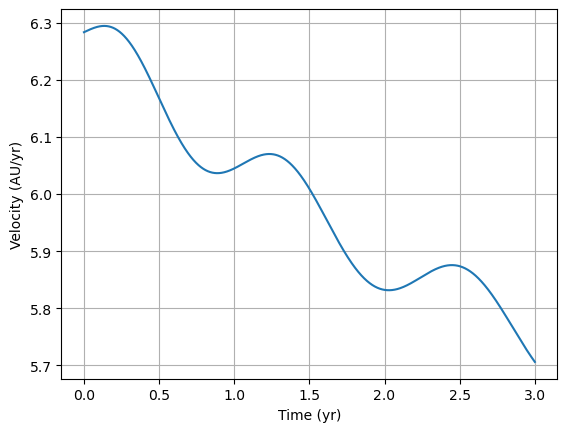

In [5]:
G = 4*np.pi**2
M = 1 #solar mass
x, y = 1,0 #AU
r = np.sqrt(x**2+y**2)
vcirc = np.sqrt(G*M/r)

x,y,vx,vy,e,t = Euler(x,y,0,vcirc,3,0.001)

plt.plot(t, np.sqrt(vx**2+vy**2))
plt.xlabel("Time (yr)")
plt.ylabel("Velocity (AU/yr)")
plt.grid()
plt.savefig("Euler_velocity.png",dpi=300)
plt.show()

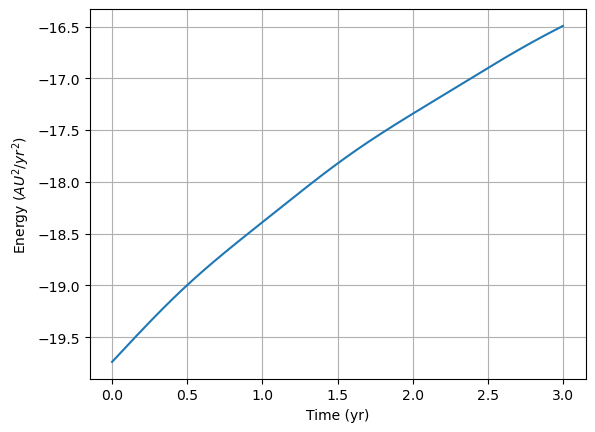

In [6]:
plt.plot(t, e)
plt.xlabel("Time (yr)")
plt.ylabel(r"Energy ($AU^{2}/yr^{2}$)")
plt.grid()
plt.savefig("Euler_energy.png",dpi=300)
plt.show()

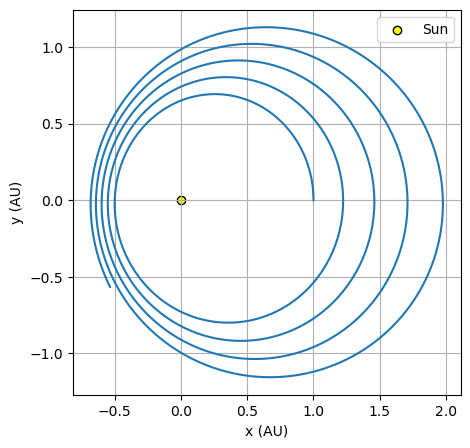

In [7]:
#0.8*vcirc
G = 4*np.pi**2
M = 1 #solar mass
x, y = 1,0 #AU
r = np.sqrt(x**2+y**2)
vcirc = np.sqrt(G*M/r)

x,y,vx,vy,e,t = Euler(x,y,0,0.8*vcirc,5,0.001)
plt.figure(figsize=(5,5))
plt.plot(x,y)
plt.scatter(0,0,color="yellow",label="Sun",alpha=1,edgecolor="black")
plt.xlabel("x (AU)")
plt.ylabel("y (AU)")
plt.grid()
plt.legend()

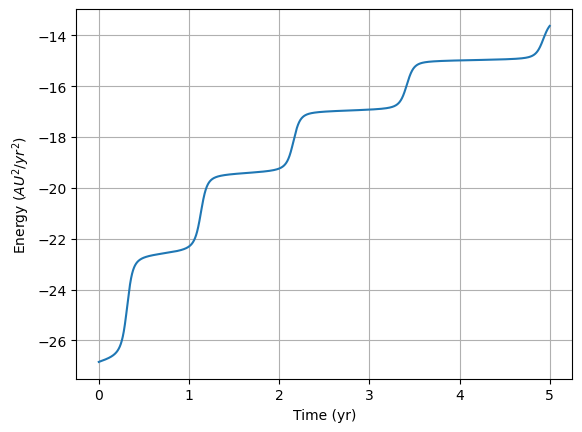

In [8]:
plt.plot(t, e)
plt.xlabel("Time (yr)")
plt.ylabel(r"Energy ($AU^{2}/yr^{2}$)")
plt.grid()
plt.savefig("Euler_5energy.png",dpi=300)
plt.show()

# Leapfrog

In [9]:
#Leapfrog
def Leapfrog(x,y,vx,vy,time,dt):

    x_vals = [x]
    y_vals = [y]
    vx_vals = [vx]
    vy_vals = [vy]
  
    #calculate initial energy
    r = np.sqrt(x**2 + y**2)
    e = 0.5*(vx**2 + vy**2) - G*M/r
    
    e_vals = [e]

    steps = int(time/dt)
    
    for i in range(steps):
        r = np.sqrt(x**2 + y**2) #compute position first
        ax = -G*M*x/r**3
        ay = -G*M*y/r**3
        
        #first kick (half-interval)
        vx_fhalf = vx + 0.5*ax*dt
        vy_fhalf = vy + 0.5*ay*dt
    
        #drift from first kick 
        x_new = x + vx_fhalf*dt
        y_new = y + vy_fhalf*dt

        #accel and energy from drift
        r_new = np.sqrt(x_new**2 + y_new**2)
        ax_drift = -G*M*x_new/r_new**3
        ay_drift = -G*M*y_new/r_new**3
    
        #second kick (half-interval) - this makes the full time step
        vx_shalf = vx_fhalf + 0.5*ax_drift*dt
        vy_shalf = vy_fhalf + 0.5*ay_drift*dt
 
        #calc energies
        e = 0.5*(vx_shalf**2 + vy_shalf**2) - G*M/r_new
    
        #updating params 
        x = x_new
        y = y_new
        vx = vx_shalf
        vy = vy_shalf

        x_vals.append(x)
        y_vals.append(y)
        vx_vals.append(vx)
        vy_vals.append(vy)
        e_vals.append(e)

    t_vals = np.linspace(0, steps*dt, steps + 1)
    
    return np.array(x_vals), np.array(y_vals), np.array(vx_vals), np.array(vy_vals), np.array(e_vals), t_vals

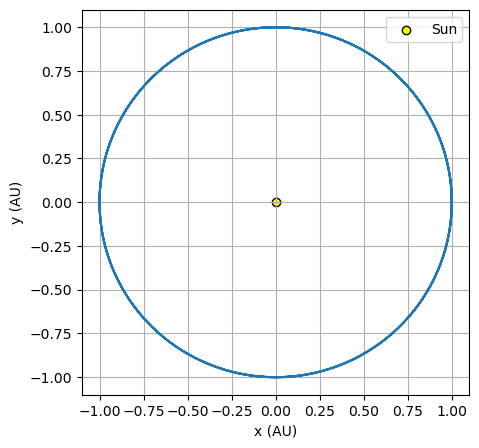

In [10]:
#testing leapfrog
G = 4*np.pi**2
M = 1 #solar mass
x, y = 1,0 #AU
r = np.sqrt(x**2+y**2)
vcirc = np.sqrt(G*M/r)

x,y,vx,vy,e,t = Leapfrog(x,y,0,vcirc,3,0.001)

plt.figure(figsize=(5,5))
plt.plot(x,y)
plt.scatter(0,0,color="yellow",label="Sun",alpha=1,edgecolor="black")
plt.xlabel("x (AU)")
plt.ylabel("y (AU)")
plt.grid()
plt.legend()
plt.show()

In [11]:
# #Figure stuff
# fig, ax = plt.subplots(figsize = (6, 6))
# ax.set_xlim(-1.5, 1.5)
# ax.set_ylim(-1.5, 1.5)
# ax.set_xlabel('x (AU)')
# ax.set_ylabel('y (AU)')
# ax.set_title('Euler Orbit')

# #Plotting stuff
# earth, = ax.plot([], [], 'bo', markersize = 6, label = 'Earth')
# trail, = ax.plot([], [], 'k-', alpha = 0.5, label = 'Orbit')
# ax.plot(0, 0, 'yo', markersize = 12, label = 'Sun')
# ax.grid()
# ax.legend()

# def init():
#     earth.set_data([], [])
#     trail.set_data([], [])
#     return earth, trail

# #Update function
# frame_step = 2 
# def update(frame):
#     idx = frame * frame_step #frame steps
#     earth.set_data([x[idx]], [y[idx]]) #earth position updates
#     trail.set_data(x[:idx], y[:idx]) #orbit trail updates
    
#     return earth, trail

# #Animation
# total_frames = len(x) // frame_step
# ani = FuncAnimation(fig, update, frames = total_frames, init_func = init, blit = True, interval = 20)
# plt.close() 

# #save as gif
# ani.save('leapfrog.gif', writer='pillow', fps=30)

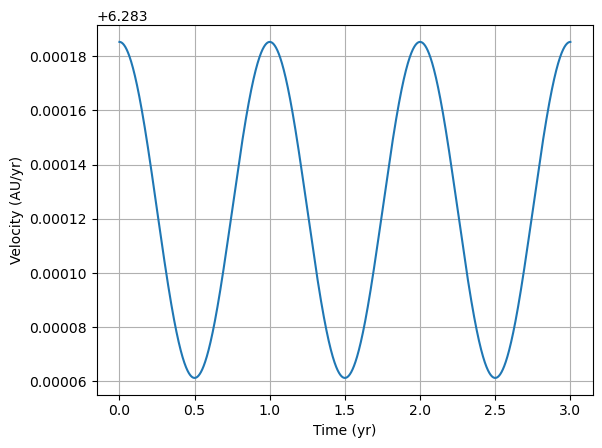

In [12]:
G = 4*np.pi**2
M = 1 #solar mass
x, y = 1,0 #AU
r = np.sqrt(x**2+y**2)
vcirc = np.sqrt(G*M/r)

x,y,vx,vy,e,t = Leapfrog(x,y,0,vcirc,3,0.001)

plt.plot(t, np.sqrt(vx**2+vy**2))
plt.xlabel("Time (yr)")
plt.ylabel("Velocity (AU/yr)")
plt.grid()
plt.savefig("Leapfrog_velocity.png",dpi=300)
plt.show()

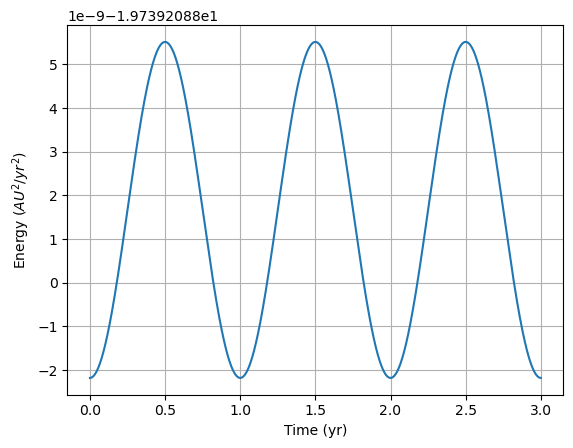

In [13]:
plt.plot(t, e)
plt.xlabel("Time (yr)")
plt.ylabel(r"Energy ($AU^{2}/yr^{2}$)")
plt.grid()
plt.savefig("Leapfrog_energy.png",dpi=300)
plt.show()

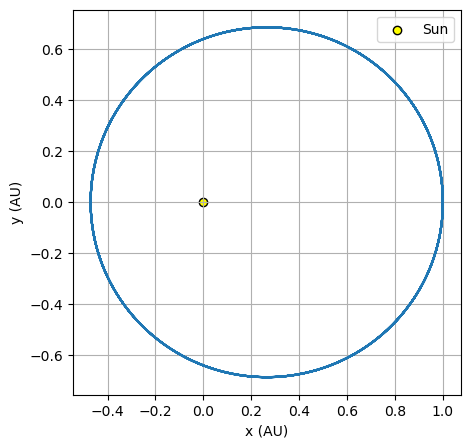

In [14]:
#0.8*vcirc
G = 4*np.pi**2
M = 1 #solar mass
x, y = 1,0 #AU
r = np.sqrt(x**2+y**2)
vcirc = np.sqrt(G*M/r)

x,y,vx,vy,e,t = Leapfrog(x,y,0,0.8*vcirc,5,0.001)
plt.figure(figsize=(5,5))
plt.plot(x,y)
plt.scatter(0,0,color="yellow",label="Sun",alpha=1,edgecolor="black")
plt.xlabel("x (AU)")
plt.ylabel("y (AU)")
plt.grid()
plt.legend()

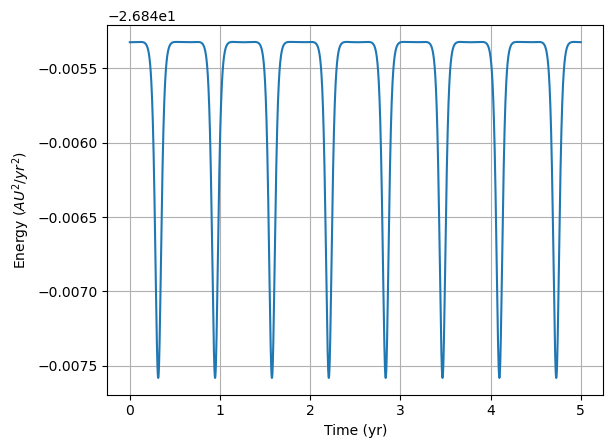

In [15]:
plt.plot(t, e)
plt.xlabel("Time (yr)")
plt.ylabel(r"Energy ($AU^{2}/yr^{2}$)")
plt.grid()
plt.savefig("Leapfrog_5energy.png",dpi=300)
plt.show()

# Comparison plots

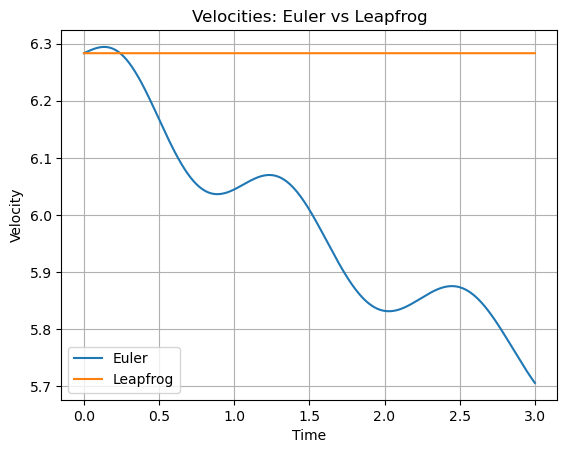

In [64]:
G = 4*np.pi**2
M = 1 #solar mass
x, y = 1,0 #AU
r = np.sqrt(x**2+y**2)
vcirc = np.sqrt(G*M/r)


xE,yE,vxE,vyE,eE,t = Euler(x,y,0,vcirc,3,0.001)
xL,yL,vxL,vyL,eL,t = Leapfrog(x,y,0,vcirc,3,0.001)


plt.plot(t, np.sqrt(vxE**2+vyE**2),label="Euler")
plt.plot(t, np.sqrt(vxL**2+vyL**2),label="Leapfrog")
plt.xlabel("Time")
plt.ylabel("Velocity")
plt.title("Velocities: Euler vs Leapfrog")
plt.grid()
plt.legend()
plt.show()

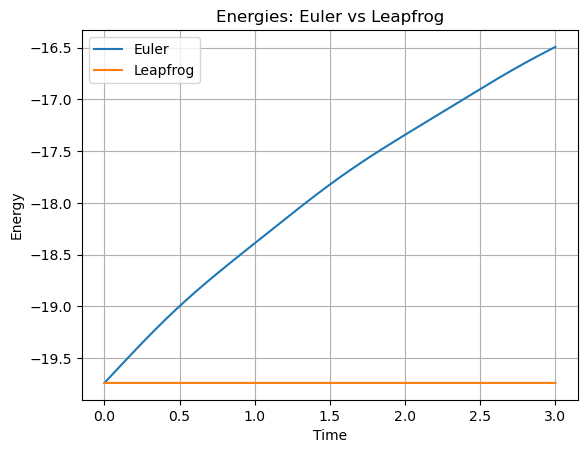

In [65]:
G = 4*np.pi**2
M = 1 #solar mass
x, y = 1,0 #AU
r = np.sqrt(x**2+y**2)
vcirc = np.sqrt(G*M/r)


xE,yE,vxE,vyE,eE,t = Euler(x,y,0,vcirc,3,0.001)
xL,yL,vxL,vyL,eL,t = Leapfrog(x,y,0,vcirc,3,0.001)


plt.plot(t, eE,label="Euler")
plt.plot(t, eL,label="Leapfrog")
plt.xlabel("Time")
plt.ylabel("Energy")
plt.title("Energies: Euler vs Leapfrog")
plt.legend()
plt.grid()
plt.show()

# Voyager

In [22]:
#Sun acting on Jupiter
G = 4*np.pi**2
M = 1 #solar mass
xJ, yJ = 0,5.2 #AU
rJ = np.sqrt(xJ**2+yJ**2)
vcircJ = np.sqrt(G*M/rJ)
vxJ, vyJ = 0, vcircJ

#Sun and Jupiter acting on Voyager
MJ = 0.0009543 #in solar masses
xV, yV = 0,1 #AU
rE = np.sqrt(xV**2+yV**2)
vcircV = np.sqrt(G*M/rE) #initial launch
vxV, vyV = 0, vcircV

#Voyager affected by the Sun and Jupiter